# 📊 Clase 1 — Fundamentos de R
### Diplomado en Visualización de Datos en R · Universidad del Valle

¡Bienvenido/a! Este notebook está pensado para que lo sigas **sin haber programado nunca antes**.

Vamos a ir paso a paso: variables → tipos de datos → paquetes → data frames → tus primeros gráficos.

**Cómo usar este notebook:** cada celda de código se ejecuta con **Shift + Enter**. Ejecuta las celdas en orden, de arriba hacia abajo.

## 1. Tu primera línea de código

En R, `print()` muestra algo en pantalla. Ejecuta la siguiente celda y observa el resultado.

In [6]:
# Ejecuta esta celda con Shift + Enter
print("¡Hola, R!")

[1] "¡Hola, R!"


## 2. Variables

Una **variable** es un espacio donde guardamos un valor para usarlo después.

En R se crean con una flecha: `<-` (se lee "asignar").

In [7]:
nombre <- "Sebastián"
edad <- 28

# Escribe el nombre de una variable sola en una celda para ver su valor
edad

[1] 28

In [8]:
nombre

[1] "Sebastián"

## 3. Tipos de datos

No todas las variables guardan el mismo tipo de información. Los tres tipos más comunes con los que vas a trabajar:

- **numeric** → números (`27`, `3.5`)
- **character** → texto, siempre entre comillas (`"Sebastián"`)
- **logical** → verdadero o falso (`TRUE` / `FALSE`)

Usamos `class()` para preguntarle a R de qué tipo es una variable.

In [9]:
class(edad)

[1] "numeric"

In [10]:
class(nombre)

[1] "character"

In [11]:
es_estudiante <- TRUE
class(es_estudiante)

[1] "logical"

## 4. Operaciones básicas

Con variables numéricas puedes hacer operaciones matemáticas normales, y con cualquier tipo puedes hacer comparaciones.

In [12]:
edad + 3      # suma

[1] 31

In [13]:
edad > 18     # comparación: ¿es mayor que 18? el resultado es un tipo logical

[1] TRUE

## 5. Paquetes

R viene con funciones básicas, pero la mayoría del trabajo real se hace con **paquetes**: colecciones de funciones que alguien más ya construyó.

El paquete que más vamos a usar en el diplomado es `tidyverse` (incluye `dplyr`, `ggplot2`, y otros).

⚠️ La primera vez que lo instalas puede tardar unos minutos — es normal, espera a que termine.

In [14]:
install.packages("tidyverse")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [15]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## 6. Vectores

Un **vector** es una lista de valores del mismo tipo. Se crean con `c()` (de "combinar").

Los vamos a necesitar para armar nuestro primer data frame.

In [16]:
ventas <- c(120, 150, 90, 200)
ventas

[1] 120 150  90 200

## 7. Data frames

Un **data frame** es una tabla: filas y columnas, como una hoja de Excel. Es la estructura de datos más importante en R — casi todo lo que hagamos en el diplomado parte de un data frame.

Vamos a crear uno simple con datos de ventas por región.

In [17]:
ventas_region <- data.frame(
  region = c("Bogotá", "Medellín", "Cali", "Barranquilla"),
  ventas = c(120, 150, 90, 200),
  mes = c("Julio", "Julio", "Julio", "Julio")
)

ventas_region

region,ventas,mes
<chr>,<dbl>,<chr>
Bogotá,120,Julio
Medellín,150,Julio
Cali,90,Julio
Barranquilla,200,Julio


## 8. Explorar un data frame

Antes de graficar cualquier cosa, siempre exploramos el data frame con estas funciones:

- `head()` → primeras filas
- `str()` → estructura y tipos de cada columna
- `dim()` → número de filas y columnas
- `names()` → nombres de las columnas
- `summary()` → estadísticas rápidas

In [18]:
head(ventas_region)

,region,ventas,mes
,<chr>,<dbl>,<chr>
1,Bogotá,120,Julio
2,Medellín,150,Julio
3,Cali,90,Julio
4,Barranquilla,200,Julio


In [19]:
str(ventas_region)

'data.frame':	4 obs. of  3 variables:
 $ region: chr  "Bogotá" "Medellín" "Cali" "Barranquilla"
 $ ventas: num  120 150 90 200
 $ mes   : chr  "Julio" "Julio" "Julio" "Julio"


In [20]:
dim(ventas_region)

[1] 4 3

In [21]:
summary(ventas_region)

       region       ventas             mes   
 Length   : 4   Min.   : 90.0   Length   :4  
 N.unique : 4   1st Qu.:112.5   N.unique :1  
 N.blank  : 0   Median :135.0   N.blank  :0  
 Min.nchar: 4   Mean   :140.0   Min.nchar:5  
 Max.nchar:12   3rd Qu.:162.5   Max.nchar:5  
                Max.   :200.0                

## 9. El pipe (`%>%`)

El **pipe** encadena pasos, uno después del otro, para que el código se lea casi como una oración: "toma esto, y luego haz esto otro".

Ejemplo: toma `ventas_region`, y luego ordénalo de mayor a menor ventas.

In [22]:
ventas_region %>%
  arrange(desc(ventas))

region,ventas,mes
<chr>,<dbl>,<chr>
Barranquilla,200,Julio
Medellín,150,Julio
Bogotá,120,Julio
Cali,90,Julio


## 10. Tus primeros gráficos con ggplot2

`ggplot2` construye gráficos por capas. La estructura básica es siempre:

```
ggplot(datos, aes(x = ..., y = ...)) + geom_algo()
```

### Gráfico de barras — ventas por región

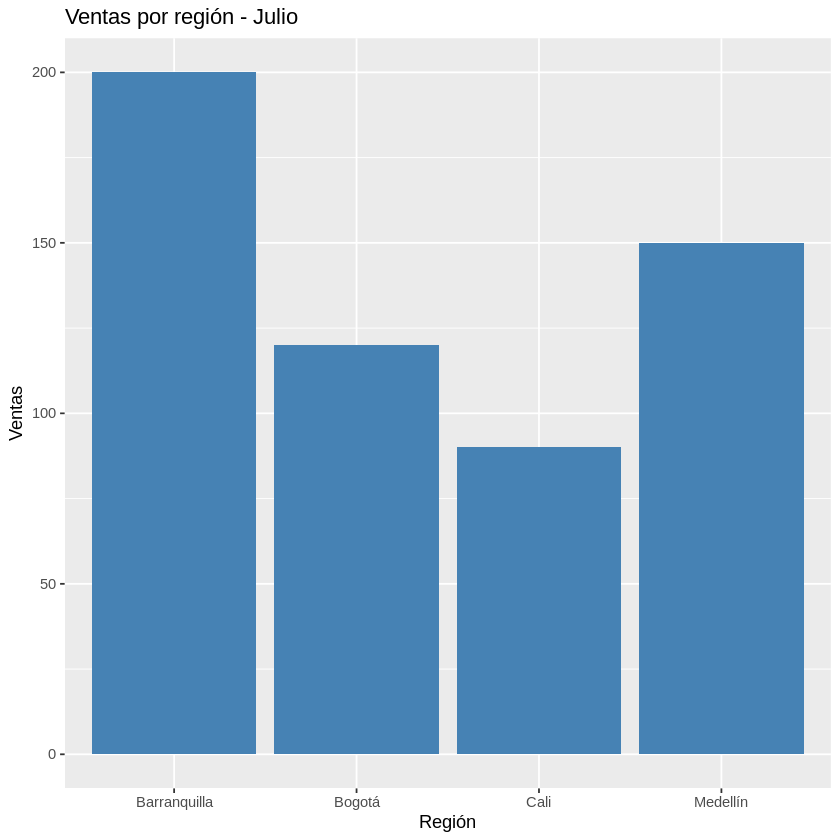

In [23]:
ggplot(ventas_region, aes(x = region, y = ventas)) +
  geom_col(fill = "steelblue") +
  labs(title = "Ventas por región - Julio",
       x = "Región",
       y = "Ventas")

### Gráfico de dispersión (simple)

Con este dataset no tenemos dos variables numéricas para un scatter clásico, así que probemos con una versión simple usando el índice de cada fila:

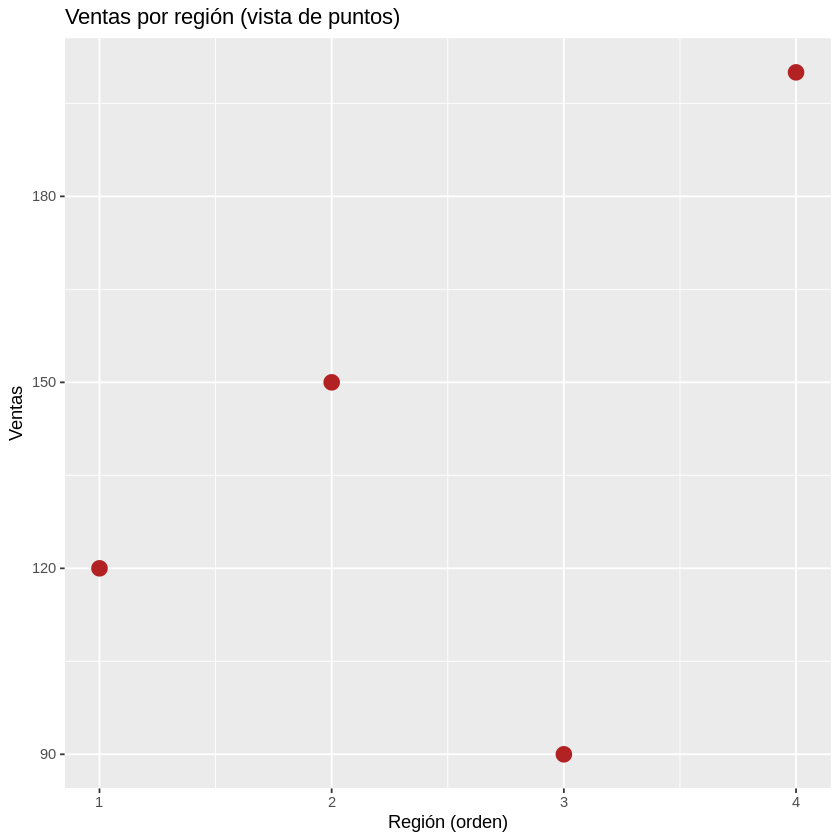

In [24]:
ventas_region$orden <- 1:nrow(ventas_region)

ggplot(ventas_region, aes(x = orden, y = ventas)) +
  geom_point(size = 4, color = "firebrick") +
  labs(title = "Ventas por región (vista de puntos)",
       x = "Región (orden)",
       y = "Ventas")

## 🎯 Resumen de hoy

Hoy aprendiste:
- ✅ Crear variables y reconocer sus tipos
- ✅ Instalar y cargar un paquete
- ✅ Crear y explorar un data frame
- ✅ Usar el pipe para encadenar pasos
- ✅ Construir tus primeros dos gráficos con `ggplot2`

## 📝 Mini-reto para practicar

Usando el mismo `ventas_region`:
1. Crea una nueva variable con el total de ventas (pista: `sum(ventas_region$ventas)`)
2. Cambia el color del gráfico de barras por uno que prefieras
3. Ordena el data frame de menor a mayor ventas usando el pipe

---
*Diplomado en Visualización de Datos en R · Universidad del Valle*
*Docente: Sebastián Barrios Caracas*